# ARX to State-Space Realization Demo

This notebook demonstrates the new deterministic SISO ARX realization utilities:

- `arx_to_state_space`
- `minimal_realization`
- `validate_realization_shapes`

It compares ARX and state-space frequency responses and shows minimal-order reduction on a synthetic example.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd()
sys.path.insert(0, str(repo_root / 'src'))

from bayes_sysid.control.realization import arx_to_state_space, minimal_realization, validate_realization_shapes

In [2]:
# Example ARX model: y[k] + a1 y[k-1] + ... = b1 u[k-1] + ...
a = np.array([0.45, -0.22, 0.06])
b = np.array([0.12, 0.05, -0.01])

A, B, C, D = arx_to_state_space(a, b, dt=0.1)
A, B, C, D = validate_realization_shapes(A, B, C, D)

print('A =\n', A)
print('B =\n', B)
print('C =\n', C)
print('D =\n', D)

A =
 [[ 0.    1.    0.  ]
 [ 0.    0.    1.  ]
 [-0.06  0.22 -0.45]]
B =
 [[0.]
 [0.]
 [1.]]
C =
 [[-0.01  0.05  0.12]]
D =
 [[0.]]


max |H_arx - H_ss| = 1.928e-16


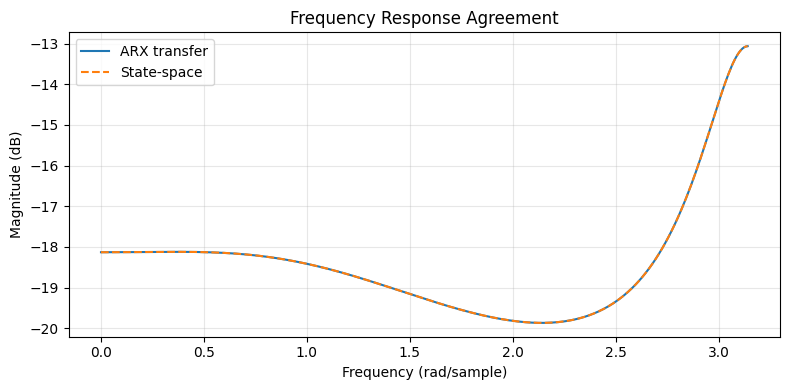

In [3]:
def arx_freq_response(a, b, w):
    z_inv = np.exp(-1j * w)
    num = np.zeros_like(z_inv, dtype=complex)
    den = np.ones_like(z_inv, dtype=complex)
    for j, bj in enumerate(b, start=1):
        num += bj * z_inv**j
    for i, ai in enumerate(a, start=1):
        den += ai * z_inv**i
    return num / den


def ss_freq_response(A, B, C, D, w):
    I = np.eye(A.shape[0])
    out = np.empty_like(w, dtype=complex)
    for k, wk in enumerate(w):
        z = np.exp(1j * wk)
        out[k] = (C @ np.linalg.solve(z * I - A, B) + D)[0, 0]
    return out


w = np.linspace(1e-3, np.pi - 1e-3, 400)
H_arx = arx_freq_response(a, b, w)
H_ss = ss_freq_response(A, B, C, D, w)

max_err = np.max(np.abs(H_arx - H_ss))
print(f'max |H_arx - H_ss| = {max_err:.3e}')

plt.figure(figsize=(8, 4))
plt.plot(w, 20 * np.log10(np.abs(H_arx) + 1e-14), label='ARX transfer')
plt.plot(w, 20 * np.log10(np.abs(H_ss) + 1e-14), '--', label='State-space')
plt.xlabel('Frequency (rad/sample)')
plt.ylabel('Magnitude (dB)')
plt.title('Frequency Response Agreement')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

In [4]:
# Synthetic model with extra unreachable/unobservable dynamics.
A_syn = np.diag([0.8, 0.5, -0.1])
B_syn = np.array([[1.0], [0.0], [0.2]])
C_syn = np.array([[1.0, 0.0, 0.0]])
D_syn = np.array([[0.0]])

A_min, B_min, C_min, D_min, kept = minimal_realization(A_syn, B_syn, C_syn, D_syn)

print('Reduced order:', A_min.shape[0])
print('Kept states:', kept)
print('A_min =\n', A_min)
print('B_min =\n', B_min)
print('C_min =\n', C_min)
print('D_min =\n', D_min)

Reduced order: 1
Kept states: [0]
A_min =
 [[0.8]]
B_min =
 [[1.]]
C_min =
 [[1.]]
D_min =
 [[0.]]


## Notes

- The realization produced by `arx_to_state_space` is in controllable companion form for proper SISO ARX models.
- `minimal_realization` trims numerically unreachable and unobservable modes based on SVD rank tests.
- This notebook can be adapted as a starting point for LQR/LQG and observer experiments on identified ARX models.